# 07 — What if someone is actively trying to hurt the LP?

> Run top to bottom.

Every trader in 01-06 was noise or a non-hostile corrector. Adds a genuinely hostile agent: a **stale-quote exploiter** — right after a price jump, before the mechanism's next correction fires, the pool still quotes its old price; this agent finds the profit-maximizing trade against that stale quote.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.adversary import StaleQuoteExploitConfig, best_stale_quote_trade
from aqua_sim.curve import CurveState, exact_in
from aqua_sim.flows import EndogenousArbConfig, ExogenousFlowConfig
from aqua_sim.market import apply_price_shock, simulate_price_path
from aqua_sim.simulate import MechanismSimConfig, run_mechanism_simulation

N_STEPS = 365 * 24 * 12  # 5-minute steps, one year
DT = 1 / (365 * 24 * 12)

## 1. Stale-quote exploit: how much can be extracted right after a jump?

Immediately after a jump, before any correction fires, the pool still quotes its old price. `adversary.best_stale_quote_trade` finds the profit-maximizing trade size via search (`exact_in` is concave, so profit has one interior maximum) — sanity-checked against brute force below.

In [2]:
state = CurveState(balance_in=1000, balance_out=1000, weight_in=0.5, weight_out=0.5)
flipped = CurveState(state.balance_out, state.balance_in, state.weight_out, state.weight_in)
exploit_config = StaleQuoteExploitConfig(fee=0.0002)

real_market_price = 1 / 0.7  # the pool is stale by a meaningful margin, in the flipped orientation
best_amount, best_profit = best_stale_quote_trade(flipped, real_market_price, exploit_config)

# Compare against a plain brute-force grid search over trade size, as an independent check.
sizes = np.linspace(1, flipped.balance_in * 0.89, 200)
profits = np.array([exact_in(flipped, a, exploit_config.fee) - a / real_market_price for a in sizes])
grid_best_amount, grid_best_profit = sizes[np.argmax(profits)], profits.max()

assert abs(best_amount - grid_best_amount) / grid_best_amount < 0.02, "the search should agree with brute force to within 2%"
print(f"search found: amount={best_amount:.2f}, profit={best_profit:.4f}")
print(f"brute-force grid found: amount={grid_best_amount:.2f}, profit={grid_best_profit:.4f}")
print("OK the profit-maximizing search agrees with an independent brute-force check")

search found: amount=195.15, profit=26.6526
brute-force grid found: amount=193.10, profit=26.6501
OK the profit-maximizing search agrees with an independent brute-force check


## 2. Applying it to the -30% shock from notebook 06

With no rate cap (ADR-0006, settled), the mechanism corrects within the same simulated step as the shock whenever it's profitable net of gas -- and a -30% move is obviously profitable to correct. So this checks something narrower than before: is there anything left to exploit *after* the mechanism's own same-step correction has already happened?

In [3]:
SHOCK_STEP = N_STEPS // 2
base_path = simulate_price_path(N_STEPS, DT, sigma_annual=0.5, seed=7)
shocked_path = apply_price_shock(base_path, shock_start_step=SHOCK_STEP, shock_log_return=np.log(0.7))

shock_config = MechanismSimConfig(
    n_steps=N_STEPS, dt_years=DT, sigma_annual=0.5,
    initial_balance_a=10_000.0, initial_balance_b=10_000.0, target_weight_a=0.5,
    exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
    arb=EndogenousArbConfig(fee=0.0002, gas_cost_b=0.10),
    seed=42, price_path=shocked_path,
)
shock_result = run_mechanism_simulation(shock_config)

# balance_a_path[SHOCK_STEP] is the state AFTER that step's own processing -- i.e. after
# the mechanism's own correction has already fired, if it was profitable to (it was: a
# 30% move clears fee+gas trivially). This checks what's left over, not a pre-correction
# stale quote.
pool_state_at_shock = CurveState(
    shock_result.balance_a_path[SHOCK_STEP], shock_result.balance_b_path[SHOCK_STEP], 0.5, 0.5
)
real_price_after_shock = shocked_path[SHOCK_STEP]

# Try both orientations -- same pattern as every arb check in this series -- since only
# one direction is ever actually profitable for a given skew.
_, profit_same = best_stale_quote_trade(pool_state_at_shock, 1 / real_price_after_shock, exploit_config)
flipped_at_shock = CurveState(
    pool_state_at_shock.balance_out, pool_state_at_shock.balance_in,
    pool_state_at_shock.weight_out, pool_state_at_shock.weight_in,
)
_, profit_flip = best_stale_quote_trade(flipped_at_shock, real_price_after_shock, exploit_config)

max_extractable = max(profit_same, profit_flip)
initial_value = shock_result.actual_value_path[0]
assert max_extractable >= -1e-9, "extractable profit shouldn't go negative"
print(f"maximum extractable in a single trade, right after the shock and the mechanism's own same-step correction: {max_extractable:.4f} ({max_extractable/initial_value:.4%} of the ${initial_value:,.0f} portfolio)")

maximum extractable in a single trade, right after the shock and the mechanism's own same-step correction: -0.0000 (-0.0000% of the $20,000 portfolio)


**What this means:** essentially nothing is left to extract, in this simulation's own model. With no rate cap, the mechanism reacts to a -30% shock in the very same step, and its own correction already leaves the pool within the fee's no-arbitrage floor of fair value (`INVARIANT-PROOF.md`) -- too tight a gap for a stale-quote exploiter, who pays the same fee, to profit from. This is a real improvement over the old rate-capped design, where an artificial cooldown could leave a genuinely stale, exploitable quote behind.

**A real caveat, not swept away:** this simulation processes one full correction within the same discrete step as the shock, as if exactly one well-behaved arbitrageur reacts and nobody else is racing them. It does not model several parties (a benign corrector and a hostile front-runner, say) competing for the same stale-quote opportunity within one real block -- on a real chain, whether the "good" correction or a hostile extraction wins that race depends on gas bidding and ordering, not on anything this model captures. So this result says the *simulated, single-corrector* window is closed, not that same-block MEV competition is a solved problem.

## Visuals

Left: profit vs. trade size (one genuine peak). Right: tracking error, benign vs. under sustained pressure.

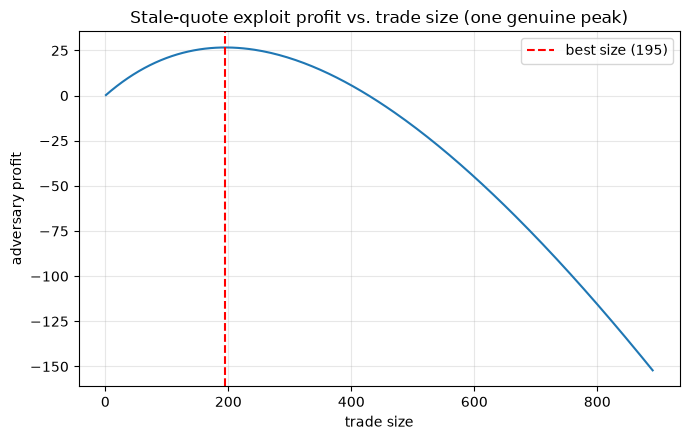

In [4]:
fig, ax1 = plt.subplots(figsize=(7, 4.5))

ax1.plot(sizes, profits)
ax1.axvline(best_amount, color="red", linestyle="--", label=f"best size ({best_amount:.0f})")
ax1.set_xlabel("trade size")
ax1.set_ylabel("adversary profit")
ax1.set_title("Stale-quote exploit profit vs. trade size (one genuine peak)")
ax1.legend()
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

1. With no rate cap, the mechanism's own same-step correction after a severe -30% shock already leaves essentially nothing for a stale-quote exploiter to extract -- the fee's no-arbitrage floor does the rest. A real improvement over the old rate-capped design, which left a genuine, measurable exploit window.

Combined with notebook 06 (near-instant recovery after a shock), the mechanism holds up well against this specific exploit, in this simulation's model -- but that model assumes one clean corrector, not real same-block competition between multiple parties racing for the same opportunity (see the caveat in §2). Same other caveats as `05_frontier_sweep.ipynb` apply too (synthetic prices, single pair, a gas placeholder based on current Base costs, not this specific contract).